In [119]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.preprocessing import StandardScaler
from pathlib import Path

In [120]:
class SigmaPredictor(nn.Module):
    def __init__(self, in_dim = 5, hidden = 64, out_dim = 5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.GELU(),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, hidden // 2),
            nn.GELU(),
            nn.Linear(hidden // 2, out_dim),
        )
    
    def forward(self, x):
        return self.net(x)

In [121]:
torch.manual_seed(100)
model_0 = SigmaPredictor()
opt = torch.optim.Adam(model_0.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.SmoothL1Loss()

In [ ]:
#loading data from csv files
df = pd.read_csv("dataset.csv")
df.head(10)
feature_col = ['z_l', 'z_s1', 'z_s2', 'sig_b', 'beta']
target_col = ['w0_sigma', 'wa_sigma', 'w0_mean', 'wa_mean', 'OmM_mean']
X = df[feature_col].values
y = df[target_col].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=100
)

In [123]:
x_scaler = StandardScaler().fit(X_train)
X_train = x_scaler.transform(X_train)
X_test  = x_scaler.transform(X_test)
y_scaler = StandardScaler().fit(y_train)

In [124]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)
y_train = torch.tensor(y_scaler.transform(y_train), dtype=torch.float32)
y_test  = torch.tensor(y_scaler.transform(y_test),  dtype=torch.float32)

In [ ]:
#defuncted training loop, no early stopping
'''
epochs = 600

for epoch in range(epochs):
    model_0.train()
    opt.zero_grad()
    pred = model_0(X_train)
    loss = loss_fn(pred, y_train)
    loss.backward()
    opt.step()

    model_0.eval()

    with torch.inference_mode():
        test_preds = model_0(X_test)
        test_loss = loss_fn(test_preds, y_test)

    if epoch % 10 == 0:
        print(f"epoch: {epoch}, loss = {loss}, test_loss = {test_loss}")
'''


epoch: 0, loss = 0.008929679170250893, test_loss = 0.020717855542898178
epoch: 10, loss = 0.00873587653040886, test_loss = 0.02111303247511387
epoch: 20, loss = 0.008746485225856304, test_loss = 0.021607190370559692
epoch: 30, loss = 0.008717771619558334, test_loss = 0.021172188222408295
epoch: 40, loss = 0.008699413388967514, test_loss = 0.02127634920179844
epoch: 50, loss = 0.008687048219144344, test_loss = 0.021236706525087357
epoch: 60, loss = 0.008675796911120415, test_loss = 0.021296635270118713
epoch: 70, loss = 0.008663645945489407, test_loss = 0.021234354004263878
epoch: 80, loss = 0.00865341629832983, test_loss = 0.021182222291827202
epoch: 90, loss = 0.008675888180732727, test_loss = 0.02081873081624508
epoch: 100, loss = 0.00886714830994606, test_loss = 0.020618658512830734
epoch: 110, loss = 0.008638674393296242, test_loss = 0.021199960261583328
epoch: 120, loss = 0.00862137321382761, test_loss = 0.021524988114833832
epoch: 130, loss = 0.008614161983132362, test_loss = 0.0

In [125]:
epochs = 1000
patience = 50
min_delta = 1e-6

best_test_loss = float('inf')
best_state = None
best_epoch = 0
epochs_no_improve = 0

for epoch in range(epochs):
    model_0.train()
    opt.zero_grad()
    pred = model_0(X_train)
    loss = loss_fn(pred, y_train)
    loss.backward()
    opt.step()

    model_0.eval()
    with torch.inference_mode():
        test_preds = model_0(X_test)
        test_loss = loss_fn(test_preds, y_test)

    # check for improvement
    if test_loss < best_test_loss - min_delta:
        best_test_loss = test_loss
        best_state = {k: v.clone() for k, v in model_0.state_dict().items()}
        best_epoch = epoch
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epoch % 10 == 0:
        print(f"epoch: {epoch}, loss = {loss}, test_loss = {test_loss}")

    if epochs_no_improve >= patience:
        print(f"Early stopping at epoch {epoch} (no improvement for {patience} epochs)")
        break

# restore the best checkpoint, not whatever the loop ended on
model_0.load_state_dict(best_state)
print(f"Restored best model from epoch {best_epoch}, test_loss = {best_test_loss:.6f}")

epoch: 0, loss = 0.16233447194099426, test_loss = 0.17148561775684357
epoch: 10, loss = 0.1500871181488037, test_loss = 0.1592891961336136
epoch: 20, loss = 0.14018622040748596, test_loss = 0.14952877163887024
epoch: 30, loss = 0.13610997796058655, test_loss = 0.14492717385292053
epoch: 40, loss = 0.13176016509532928, test_loss = 0.1395753175020218
epoch: 50, loss = 0.12719564139842987, test_loss = 0.13446903228759766
epoch: 60, loss = 0.12212862819433212, test_loss = 0.12859567999839783
epoch: 70, loss = 0.11663796007633209, test_loss = 0.12227871268987656
epoch: 80, loss = 0.1108212098479271, test_loss = 0.11594822257757187
epoch: 90, loss = 0.10465505719184875, test_loss = 0.10956727713346481
epoch: 100, loss = 0.0980718806385994, test_loss = 0.1027100458741188
epoch: 110, loss = 0.09054780006408691, test_loss = 0.09430593997240067
epoch: 120, loss = 0.08213280886411667, test_loss = 0.08465442806482315
epoch: 130, loss = 0.07323306798934937, test_loss = 0.07473979145288467
epoch: 14

In [127]:
model_0.eval()

sig_b_idx = feature_col.index('sig_b')  # find its column position

def sensitivity_at_point(x_row_scaled):
    """x_row_scaled: 1D tensor, already in scaled feature space"""
    x = x_row_scaled.clone().detach().requires_grad_(True)
    pred = model_0(x.unsqueeze(0))  # shape (1, 5)

    grads = []
    for i in range(pred.shape[1]):
        grad = torch.autograd.grad(pred[0, i], x, retain_graph=True)[0]
        grads.append(grad[sig_b_idx].item())
    return dict(zip(target_col, grads))


In [128]:
x_sample = X_test[0]
print(sensitivity_at_point(x_sample))

{'w0_sigma': -0.18850013613700867, 'wa_sigma': 0.03885895013809204, 'w0_mean': -0.23344382643699646, 'wa_mean': 0.4101312756538391, 'OmM_mean': -0.17337433993816376}


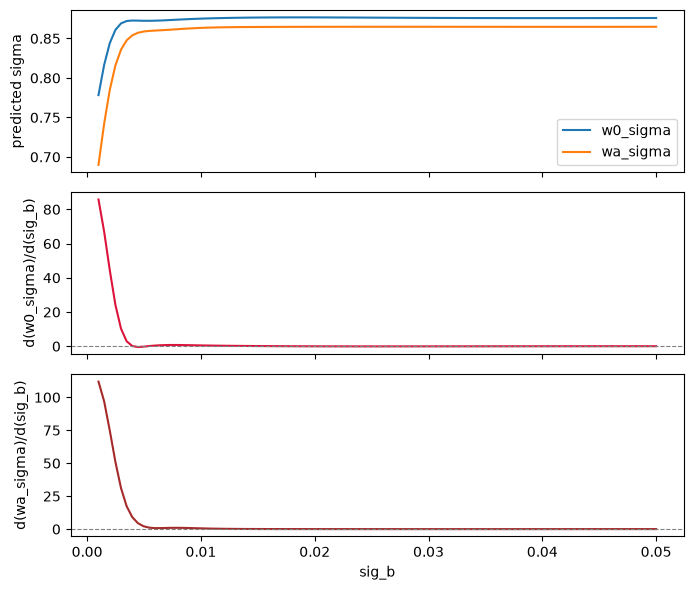

In [129]:
X_train_raw = x_scaler.inverse_transform(X_train.numpy())
baseline_raw = np.median(X_train_raw, axis=0)

sig_b_raw_range = np.linspace(X_train_raw[:, sig_b_idx].min(),
                                X_train_raw[:, sig_b_idx].max(), 100)

preds_raw = []
grads_w0_raw = []
grads_wa_raw = []

for sb in sig_b_raw_range:
    x_raw = baseline_raw.copy()
    x_raw[sig_b_idx] = sb
    x_scaled = x_scaler.transform(x_raw.reshape(1, -1))[0]

    x_t = torch.tensor(x_scaled, dtype=torch.float32, requires_grad=True)
    pred_scaled = model_0(x_t.unsqueeze(0))
    pred_raw = y_scaler.inverse_transform(pred_scaled.detach().numpy())[0]
    preds_raw.append(pred_raw)

    grad_w0 = torch.autograd.grad(pred_scaled[0, 0], x_t, retain_graph=True)[0][sig_b_idx].item()
    grad_w0_raw = grad_w0 * y_scaler.scale_[0] / x_scaler.scale_[sig_b_idx]
    grads_w0_raw.append(grad_w0_raw)

    grad_wa = torch.autograd.grad(pred_scaled[0, 1], x_t)[0][sig_b_idx].item()
    grad_wa_raw = grad_wa * y_scaler.scale_[1] / x_scaler.scale_[sig_b_idx]
    grads_wa_raw.append(grad_wa_raw)

preds_raw = np.array(preds_raw)

fig, axs = plt.subplots(3, 1, figsize=(7, 6), sharex=True)
axs[0].plot(sig_b_raw_range, preds_raw[:, 0], label='w0_sigma')
axs[0].plot(sig_b_raw_range, preds_raw[:, 1], label='wa_sigma')
axs[0].set_ylabel('predicted sigma')
axs[0].legend()

axs[1].plot(sig_b_raw_range, grads_w0_raw, color='crimson')
axs[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axs[1].set_ylabel('d(w0_sigma)/d(sig_b)')

axs[2].plot(sig_b_raw_range, grads_wa_raw, color='brown')
axs[2].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axs[2].set_ylabel('d(wa_sigma)/d(sig_b)')
axs[2].set_xlabel('sig_b')

plt.tight_layout()
plt.show()

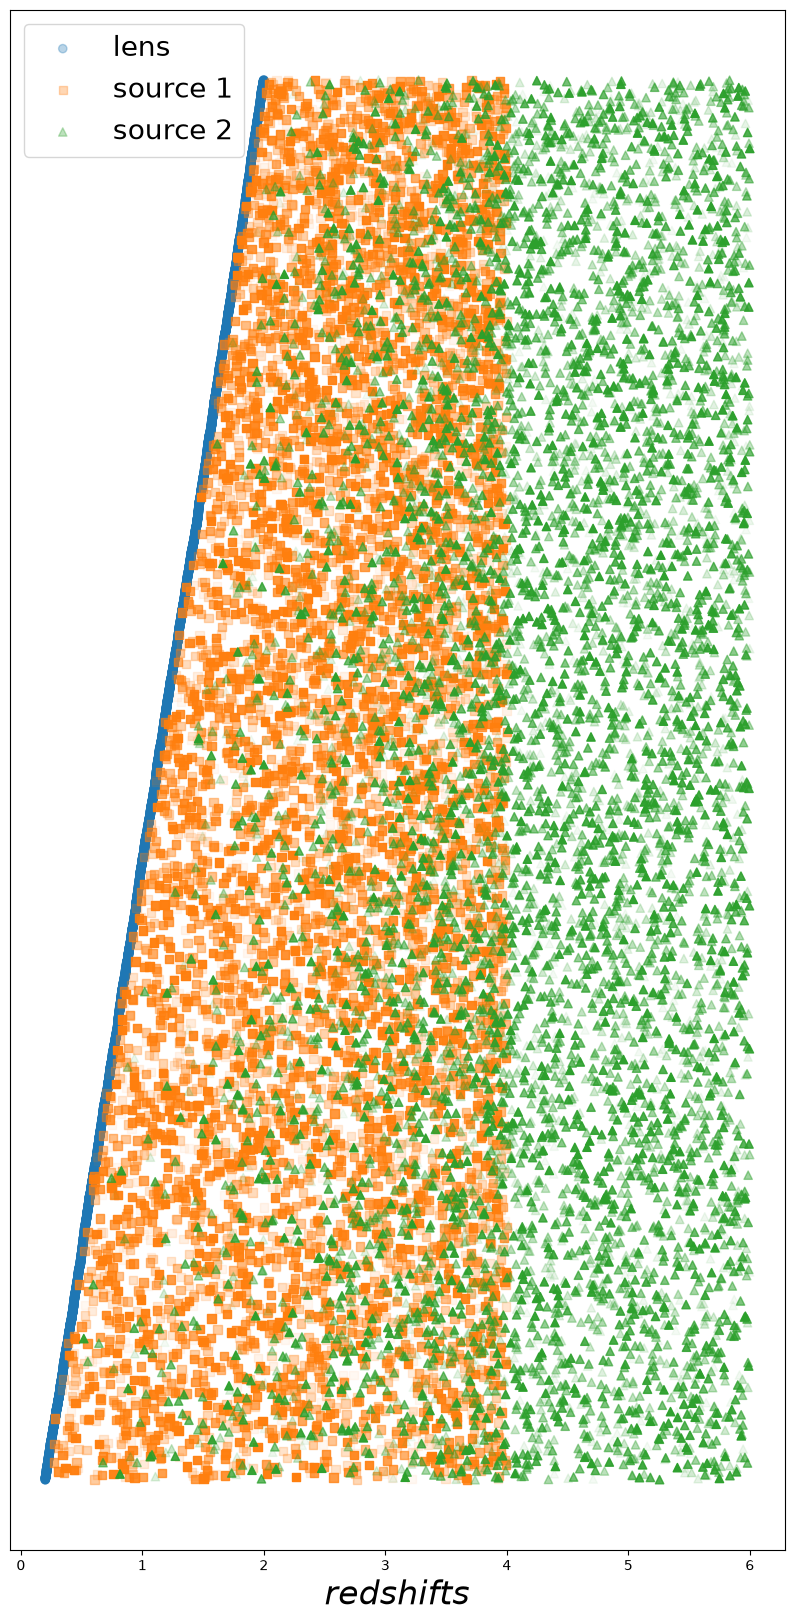

In [130]:
import numpy as np
import matplotlib.pyplot as plt

df_sorted = df.sort_values(by='z_l').reset_index(drop=True)

zl_sort    = df_sorted['z_l'].values
zs1_sort   = df_sorted['z_s1'].values
zs2_sort   = df_sorted['z_s2'].values
sig_b_sort = df_sorted['sig_b'].values

num = len(df_sorted)
i = np.linspace(0, num, num)

# normalize sig_b to [0, 1], then invert so bigger sig_b -> lower alpha (lighter)
sig_b_norm = (sig_b_sort - sig_b_sort.min()) / (sig_b_sort.max() - sig_b_sort.min())
alphas = 1 - sig_b_norm
alphas = np.clip(alphas, 0.05, 1.0)  # keep a floor so points don't vanish completely

plt.subplots(figsize=(10, 20))
plt.tick_params(left=False, labelleft=False)

plt.scatter(zl_sort,  i, marker="o", label="lens",     alpha=alphas, color="tab:blue")
plt.scatter(zs1_sort, i, marker="s", label="source 1", alpha=alphas, color="tab:orange")
plt.scatter(zs2_sort, i, marker="^", label="source 2", alpha=alphas, color="tab:green")

plt.xlabel("$redshifts$", fontsize=24)
plt.legend(fontsize=20)
plt.show()

In [131]:
print(df['sig_b'].describe())

count    7000.000000
mean        0.025173
std         0.013997
min         0.001000
25%         0.013077
50%         0.025195
75%         0.037127
max         0.049999
Name: sig_b, dtype: float64


In [132]:
MODEL_DIC = Path("models")
MODEL_DIC.mkdir(parents=True, exist_ok=True)

In [133]:
SAVE_PATH = MODEL_DIC / 'model_0.pth'
torch.save(model_0.state_dict(), SAVE_PATH)

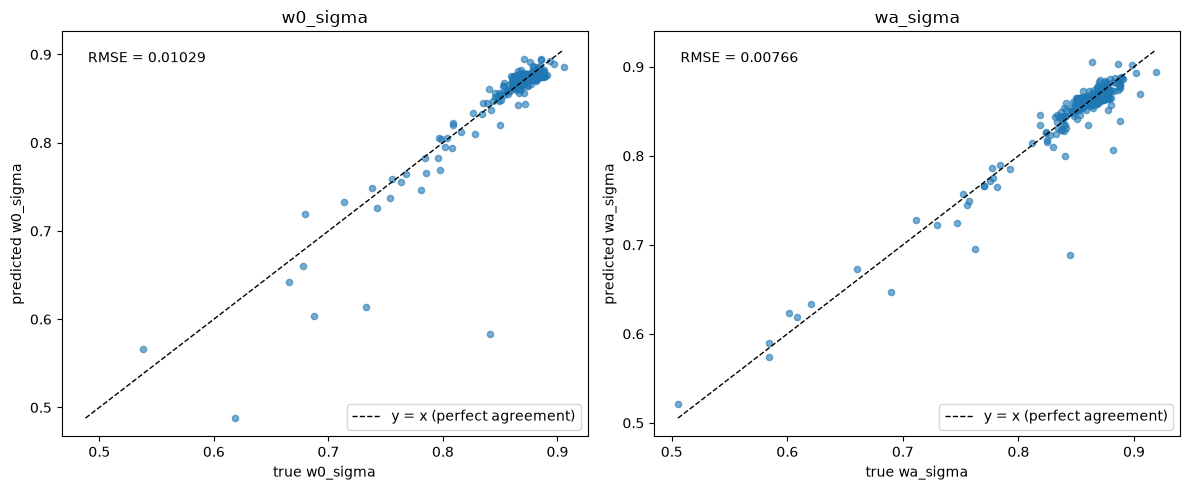

In [134]:
model_0.eval()
with torch.inference_mode():
    test_preds_scaled = model_0(X_test)

test_preds_raw = y_scaler.inverse_transform(test_preds_scaled.numpy())
test_true_raw  = y_scaler.inverse_transform(y_test.numpy())

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

for idx, name in [(0, 'w0_sigma'), (1, 'wa_sigma')]:
    ax = axs[idx]
    true_vals = test_true_raw[:, idx]
    pred_vals = test_preds_raw[:, idx]

    ax.scatter(true_vals, pred_vals, alpha=0.6, s=20)
    lims = [min(true_vals.min(), pred_vals.min()), max(true_vals.max(), pred_vals.max())]
    ax.plot(lims, lims, 'k--', linewidth=1, label='y = x (perfect agreement)')
    ax.set_xlabel(f'true {name}')
    ax.set_ylabel(f'predicted {name}')
    ax.set_title(name)
    ax.legend()

    residuals = pred_vals - true_vals
    rmse = np.sqrt(np.mean(residuals**2))
    ax.text(0.05, 0.95, f'RMSE = {rmse:.5f}', transform=ax.transAxes,
            va='top', fontsize=10)

plt.tight_layout()
plt.show()

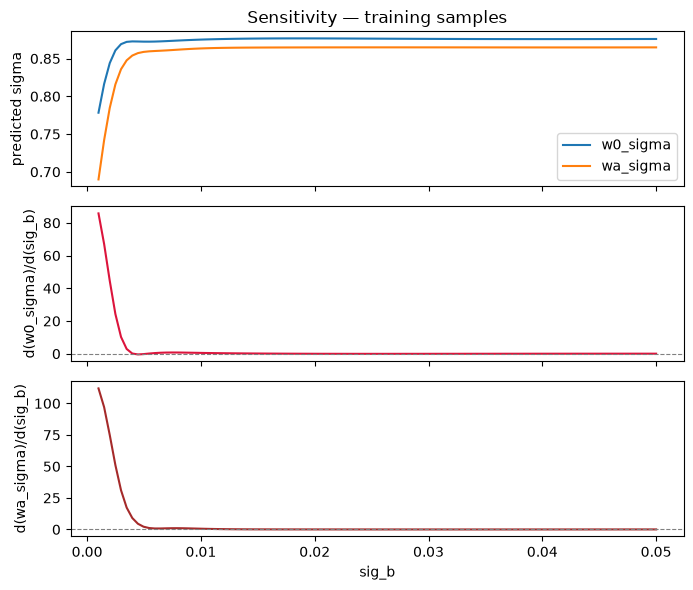

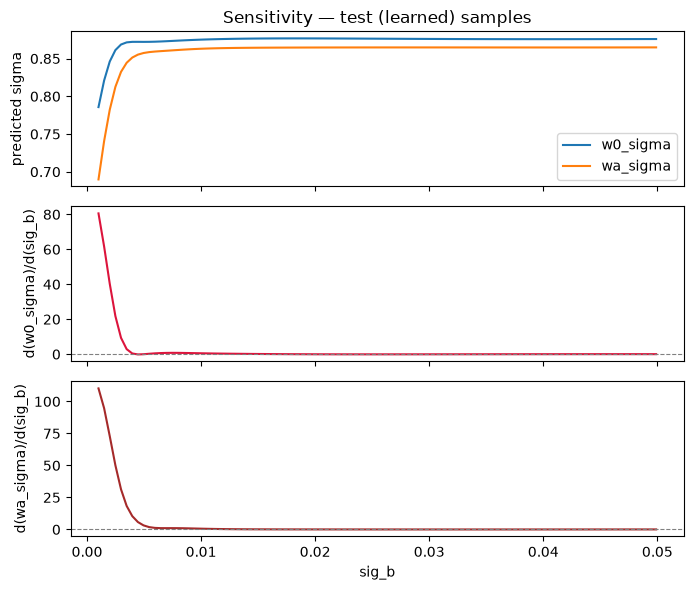

(array([[ 0.7857253 ,  0.68984914, -0.6471173 , -0.97053295,  0.33230838],
        [ 0.8210242 ,  0.7407659 , -0.61977124, -1.0840952 ,  0.33568317],
        [ 0.846159  ,  0.7822911 , -0.59804636, -1.1772718 ,  0.33831248],
        [ 0.8612741 ,  0.8125725 , -0.58170986, -1.2498198 ,  0.34020913],
        [ 0.8686947 ,  0.8324511 , -0.5698186 , -1.3042592 ,  0.34151652],
        [ 0.87150645,  0.84448075, -0.56124765, -1.344208  ,  0.34241802],
        [ 0.8722047 ,  0.85140395, -0.5550543 , -1.3730526 ,  0.34305987],
        [ 0.8722249 ,  0.85528284, -0.5505537 , -1.3935333 ,  0.34353095],
        [ 0.8721741 ,  0.8574223 , -0.5472463 , -1.4078854 ,  0.3438814 ],
        [ 0.87223023,  0.85861254, -0.54475164, -1.4179941 ,  0.3441448 ],
        [ 0.8724107 ,  0.8593363 , -0.5427882 , -1.42538   ,  0.34434786],
        [ 0.8726889 ,  0.8598755 , -0.54117024, -1.4311275 ,  0.34451118],
        [ 0.8730307 ,  0.86037004, -0.53979367, -1.4358927 ,  0.34464845],
        [ 0.87340444,  0.

In [135]:
X_train_raw = x_scaler.inverse_transform(X_train.numpy())
X_test_raw  = x_scaler.inverse_transform(X_test.numpy())

def sensitivity_sweep_plot(baseline_raw, sig_b_range, title):
    preds_raw = []
    grads_w0_raw = []
    grads_wa_raw = []

    for sb in sig_b_range:
        x_raw = baseline_raw.copy()
        x_raw[sig_b_idx] = sb
        x_scaled = x_scaler.transform(x_raw.reshape(1, -1))[0]

        x_t = torch.tensor(x_scaled, dtype=torch.float32, requires_grad=True)
        pred_scaled = model_0(x_t.unsqueeze(0))
        pred_raw = y_scaler.inverse_transform(pred_scaled.detach().numpy())[0]
        preds_raw.append(pred_raw)

        grad_w0 = torch.autograd.grad(pred_scaled[0, 0], x_t, retain_graph=True)[0][sig_b_idx].item()
        grads_w0_raw.append(grad_w0 * y_scaler.scale_[0] / x_scaler.scale_[sig_b_idx])

        grad_wa = torch.autograd.grad(pred_scaled[0, 1], x_t)[0][sig_b_idx].item()
        grads_wa_raw.append(grad_wa * y_scaler.scale_[1] / x_scaler.scale_[sig_b_idx])

    preds_raw = np.array(preds_raw)

    fig, axs = plt.subplots(3, 1, figsize=(7, 6), sharex=True)
    axs[0].plot(sig_b_range, preds_raw[:, 0], label='w0_sigma')
    axs[0].plot(sig_b_range, preds_raw[:, 1], label='wa_sigma')
    axs[0].set_ylabel('predicted sigma')
    axs[0].set_title(title)
    axs[0].legend()

    axs[1].plot(sig_b_range, grads_w0_raw, color='crimson')
    axs[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
    axs[1].set_ylabel('d(w0_sigma)/d(sig_b)')

    axs[2].plot(sig_b_range, grads_wa_raw, color='brown')
    axs[2].axhline(0, color='gray', linestyle='--', linewidth=0.8)
    axs[2].set_ylabel('d(wa_sigma)/d(sig_b)')
    axs[2].set_xlabel('sig_b')

    plt.tight_layout()
    plt.show()

    return preds_raw, grads_w0_raw, grads_wa_raw

# training samples: baseline + sig_b range both drawn from training data
baseline_train = np.median(X_train_raw, axis=0)
sig_b_range_train = np.linspace(X_train_raw[:, sig_b_idx].min(),
                                  X_train_raw[:, sig_b_idx].max(), 100)
sensitivity_sweep_plot(baseline_train, sig_b_range_train, "Sensitivity — training samples")

# test/learned samples: baseline + sig_b range both drawn from test data
baseline_test = np.median(X_test_raw, axis=0)
sig_b_range_test = np.linspace(X_test_raw[:, sig_b_idx].min(),
                                 X_test_raw[:, sig_b_idx].max(), 100)
sensitivity_sweep_plot(baseline_test, sig_b_range_test, "Sensitivity — test (learned) samples")

In [136]:
# raw-unit target values
y_train_raw = y_scaler.inverse_transform(y_train.numpy())
y_test_raw  = y_scaler.inverse_transform(y_test.numpy())

for idx, name in enumerate(target_col):
    std_train = y_train_raw[:, idx].std()
    std_test  = y_test_raw[:, idx].std()
    print(f"{name}: train_std={std_train:.5f}, test_std={std_test:.5f}")

w0_sigma: train_std=0.02649, test_std=0.02068
wa_sigma: train_std=0.02668, test_std=0.02374
w0_mean: train_std=0.02866, test_std=0.02920
wa_mean: train_std=0.09827, test_std=0.09647
OmM_mean: train_std=0.00316, test_std=0.00318


In [137]:
print(dict(zip(target_col, y_scaler.scale_)))

{'w0_sigma': np.float64(0.02648936023061789), 'wa_sigma': np.float64(0.026684411206348922), 'w0_mean': np.float64(0.02866417453788548), 'wa_mean': np.float64(0.09826710594673684), 'OmM_mean': np.float64(0.00315867766356912)}


In [138]:
model_0.eval()
with torch.inference_mode():
    test_preds_scaled = model_0(X_test)

test_preds_raw = y_scaler.inverse_transform(test_preds_scaled.numpy())
test_true_raw  = y_scaler.inverse_transform(y_test.numpy())

print(f"{'target':12s} {'RMSE':>10s} {'target std':>12s} {'RMSE/std':>10s}")
for idx, name in enumerate(target_col):
    residuals = test_preds_raw[:, idx] - test_true_raw[:, idx]
    rmse = np.sqrt(np.mean(residuals**2))
    std = test_true_raw[:, idx].std()
    ratio = rmse / std
    print(f"{name:12s} {rmse:10.5f} {std:12.5f} {ratio:10.3f}")

target             RMSE   target std   RMSE/std
w0_sigma        0.01029      0.02068      0.497
wa_sigma        0.00766      0.02374      0.323
w0_mean         0.00673      0.02920      0.230
wa_mean         0.01986      0.09647      0.206
OmM_mean        0.00078      0.00318      0.245


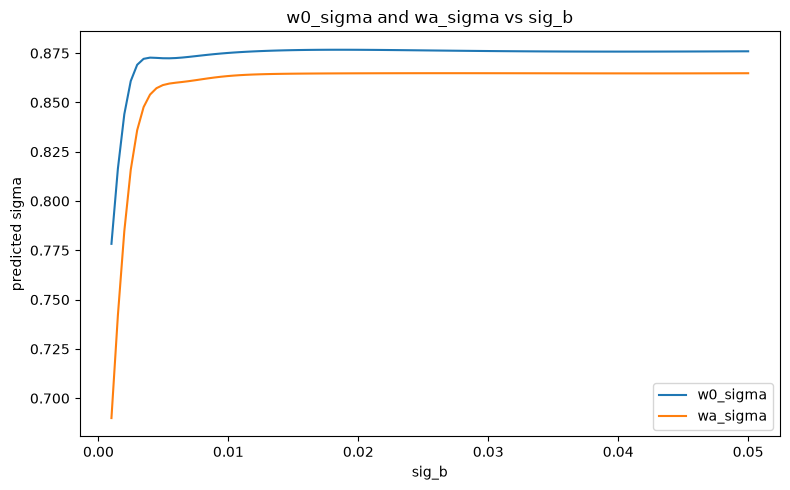

In [141]:
sig_b_range = np.linspace(0.001, 0.05, 100)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sig_b_range, preds_raw[:, 0], label='w0_sigma')
ax.plot(sig_b_range, preds_raw[:, 1], label='wa_sigma')
ax.set_xlabel('sig_b')
ax.set_ylabel('predicted sigma')
ax.set_title('w0_sigma and wa_sigma vs sig_b')
ax.legend()
plt.tight_layout()
plt.show()